In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("UberDataset.csv")
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [4]:
df.isnull().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [5]:
df["PURPOSE"]=df["PURPOSE"].fillna("Not Disclosed")

In [6]:
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df["START_DATE"]=pd.to_datetime(df["START_DATE"],format="mixed",errors="coerce")
df["END_DATE"]=pd.to_datetime(df["END_DATE"],format="mixed",errors="coerce")

In [11]:
df["Date"]=pd.DatetimeIndex(df["START_DATE"]).date
df["Time"]=pd.DatetimeIndex(df["START_DATE"]).hour

In [12]:
df["Time_of_Day"]=pd.cut(x=df["Time"],bins=[-1,11,15,19,24],labels=["morning","afternoon","evening","night"])

In [13]:
df["Day"]=pd.DatetimeIndex(df["Date"]).weekday
mapping={0:"Mon", 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
df["Day"]=df["Day"].map(mapping)

In [14]:
df["Month"]=pd.DatetimeIndex(df["Date"]).month
monthlab={1:"january",2:"february",3:"march",4:"april",5:"may",6:"june",7:"july",8:"august",9:"september",10:"october",11:"november",12:"december"}
df["Month"]=df["Month"].map(monthlab)
df.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,Date,Time,Time_of_Day,Day,Month
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,night,Fri,january
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,Not Disclosed,2016-01-02,1,morning,Sat,january
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,night,Sat,january
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,evening,Tue,january
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,afternoon,Wed,january


# Frequency of travel on Day Basis

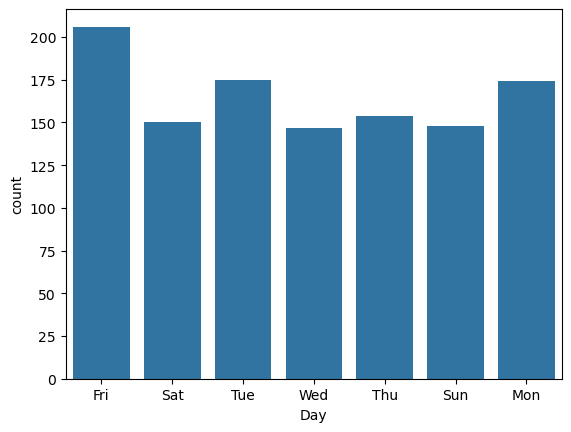

In [15]:
sns.countplot(x=df["Day"])
plt.show()

### Conclusion:
**Friday has highest number of travel followed by monday and tuesday**

# Frequency in different times of a Day

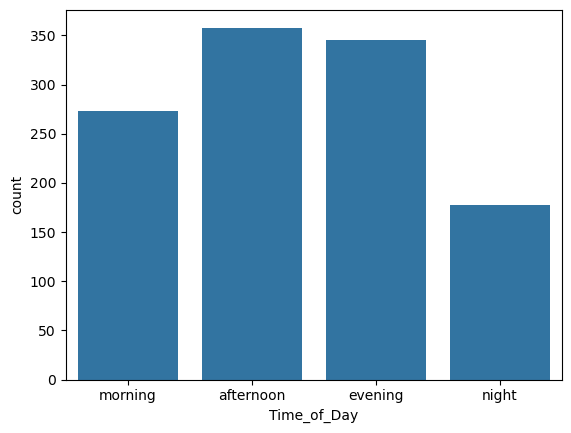

In [16]:
sns.countplot(x=df["Time_of_Day"])
plt.show()

### Conclusion:
**Most of the travel happens in between afternoon and evening**

# Comparing frequency and average distance on different Months

In [17]:
month_= df["Month"].value_counts(sort=False)
df_month=pd.DataFrame({"Monthly_Count":month_.values,"AverageMiles":df["MILES"].groupby(by=df["Month"], sort=False).mean()})

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df_month[["Monthly_Count","AverageMiles"]]=scaler.fit_transform(df_month[["Monthly_Count","AverageMiles"]])

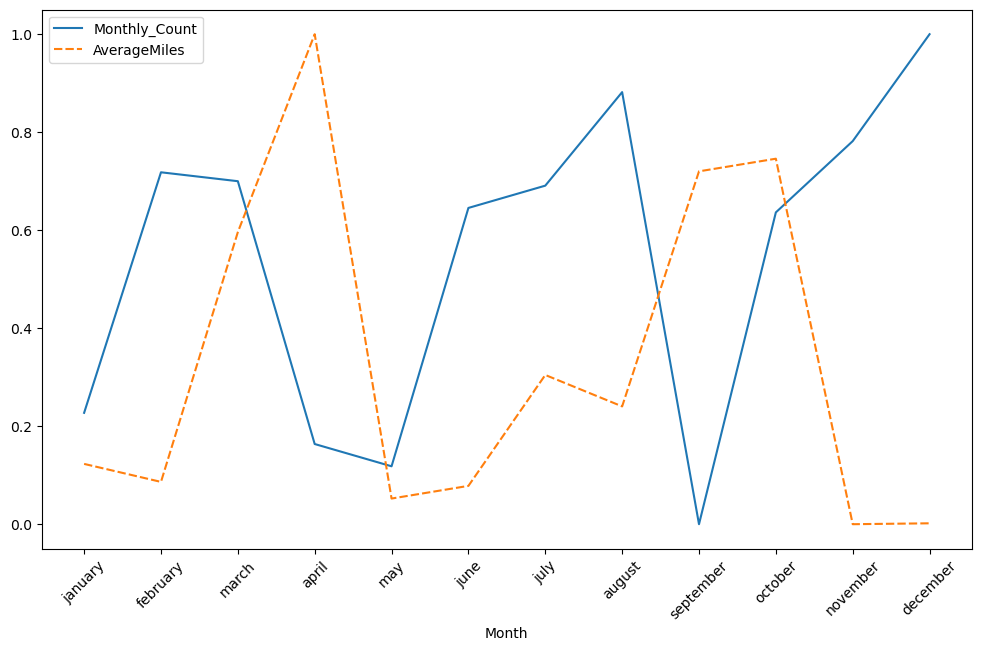

In [19]:
plt.figure(figsize=(12,7))
sns.lineplot(data=df_month)
plt.xticks(rotation=45)
plt.show()

### Conclusion:
**Except for the month of May the decline in frequency is compensated by distance travelled. But May month experiencing huge decline in frequency and travel distance.**

# Purpose and Category of Travel

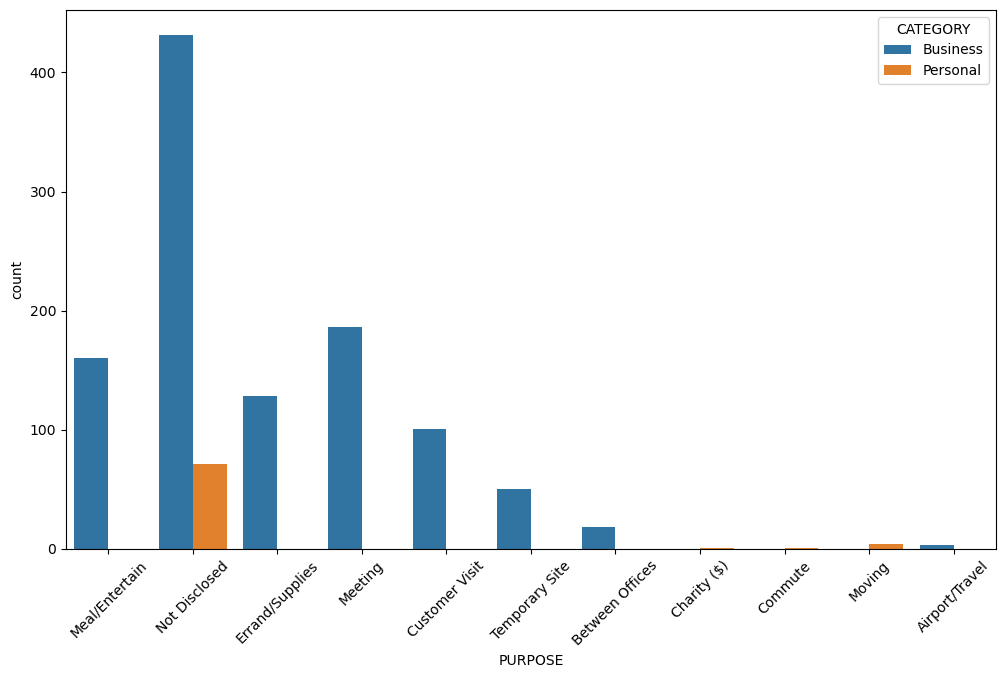

In [20]:
plt.figure(figsize=(12,7))
sns.countplot(x=df["PURPOSE"],hue=df["CATEGORY"])
plt.xticks(rotation=45)
plt.show()

### Conclusion:
**Most of the travel are Business Category and majority of its purpose is not disclosed followed by meeting and meal/entertainment. In Personal category majority of its purpose is not disclosed**

# Most frequently travelling Distance

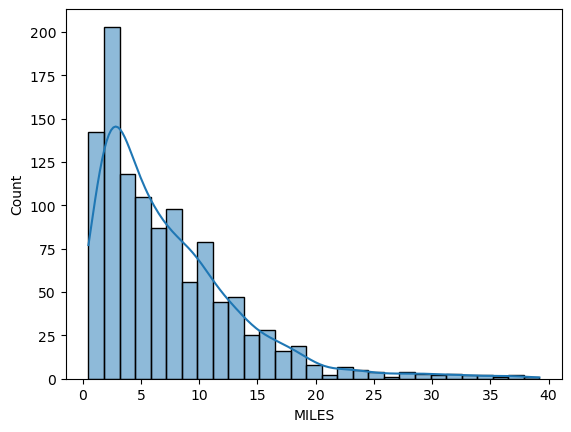

In [21]:
sns.histplot(x=df["MILES"][df["MILES"]<40],kde=True)
plt.show()

### Conclusion:
**Between 1 to 5 Miles is the most frequently travelled distance**

# Correlation HeatMap

In [22]:
from sklearn.preprocessing import OneHotEncoder
oh=OneHotEncoder(sparse_output=False, handle_unknown="ignore")
OH_data=pd.DataFrame(oh.fit_transform(df[["CATEGORY","PURPOSE"]]))
OH_data.index=df.index
OH_data.columns=oh.get_feature_names_out()
num_data=df.select_dtypes("number")
Combined_df=pd.concat([OH_data,num_data],axis=1)

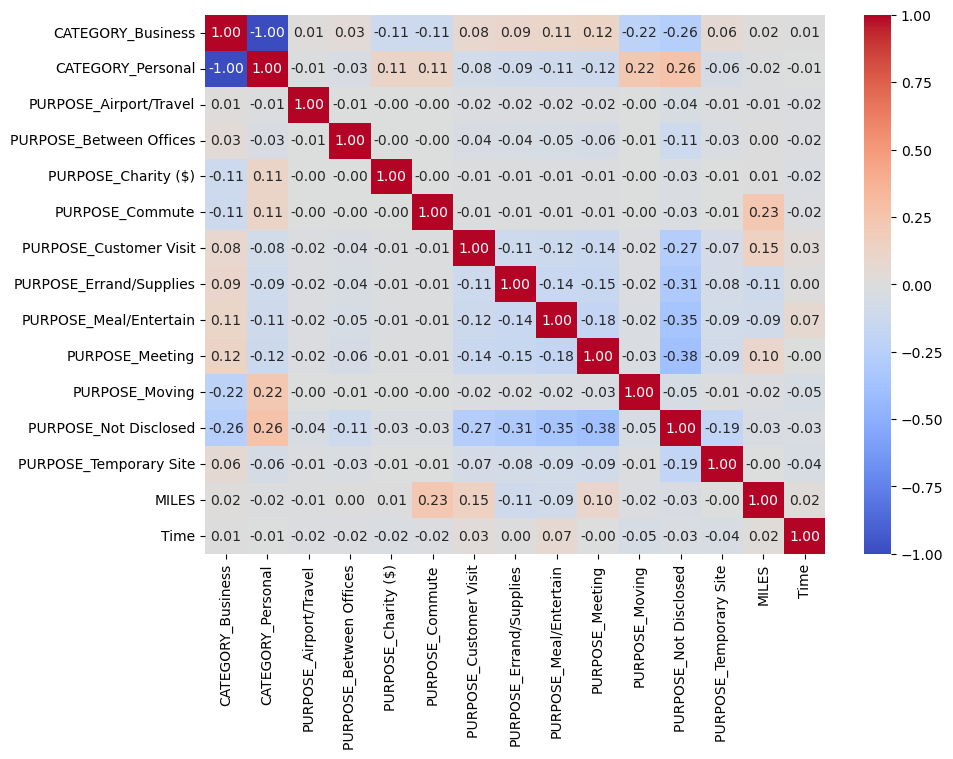

In [23]:
plt.figure(figsize=(10,7))
sns.heatmap(data=Combined_df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

### Conclusion:
**confirmed no multicollinearity issues**